# FDA Drug Adverse Event Signal Detection & Pharmacovigilance Analysis
## Identifying Safety Signals Across High-Volume Pharmaceutical Products

### Project Overview
This analysis applies pharmacovigilance methodology to the FDA Adverse Event 
Reporting System (FAERS) to detect drug safety signals across five high-volume 
pharmaceutical products. Using the Reporting Odds Ratio (ROR), the industry 
standard signal detection method used by regulatory data teams at major 
pharmaceutical organisations, this project identifies statistically elevated 
adverse event patterns, seasonal trends, demographic risk profiles and 
longitudinal performance across Aspirin, Ibuprofen, Paracetamol, Metformin 
and Atorvastatin.

### Objectives
- Detect adverse event safety signals using Reporting Odds Ratio methodology
- Analyse monthly and quarterly adverse event volume trends
- Compare serious event and death rates across five pharmaceutical products
- Identify demographic risk profiles by age group and sex
- Measure seasonal variation in adverse event reporting
- Track longitudinal trends in hospitalisation and mortality rates
- Present findings in an interactive Power BI dashboard

### Tools and Technologies
| Tool | Purpose |
|---|---|
| Python 3.12 | Core programming language |
| pandas | Data manipulation and transformation |
| numpy | Statistical calculations |
| matplotlib | Data visualisation |
| seaborn | Statistical visualisation |
| scipy | Signal detection statistics |
| PostgreSQL 16 | Database storage and SQL analysis |
| SQLAlchemy | Python to PostgreSQL connection |
| psycopg2 | PostgreSQL database adapter |
| Jupyter Lab | Interactive analysis environment |
| Power BI Desktop | Interactive dashboard |
| openFDA API | Primary data source |
| Git | Version control |

### Data Source
| | |
|---|---|
| **Publisher** | U.S. Food and Drug Administration |
| **Dataset** | FDA Adverse Event Reporting System (FAERS) |
| **Access** | openFDA API open.fda.gov/apis/drug/event |
| **Coverage** | Post-market adverse event reports 2004 to present |
| **Frequency** | Quarterly updates |
| **Licence** | Public domain CC0 |

*Analysis conducted by Kingsley Eboh | GitHub: Kingsley-Eboh*

In [1]:
# Step 1: Import Libraries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

All libraries loaded successfully
pandas: 3.0.3
numpy: 2.4.6


### Section 1: Data Acquisition
Adverse event data was retrieved from the FDA Adverse Event Reporting System 
(FAERS) via the openFDA API for five high volume pharmaceutical products: 
Aspirin, Ibuprofen, Paracetamol, Metformin and Atorvastatin. The data pull 
was restricted to reports received between January 2022 and December 2025 
to ensure the analysis reflected current post-market safety surveillance 
activity.

In [2]:

# Section 1: Data Acquisition
import time

base_url = "https://api.fda.gov/drug/event.json"
api_key = "YOUR_API_KEY_HERE"

drugs = [
    "aspirin",
    "ibuprofen",
    "paracetamol",
    "acetaminophen",
    "metformin",
    "atorvastatin"
]

def pull_fda_data(drug_name, limit=1000):
    params = {
        "search": f"patient.drug.medicinalproduct:{drug_name} AND receivedate:[20220101 TO 20251231]",
        "limit": limit,
        "api_key": api_key
    }
    try:
        response = requests.get(base_url, params=params, timeout=30)
        if response.status_code == 200:
            data = response.json()
            print(f"{drug_name}: {data['meta']['results']['total']:,} total records available")
            return data['results']
        else:
            print(f"{drug_name}: Error {response.status_code}")
            return []
    except Exception as e:
        print(f"{drug_name}: Failed - {str(e)}")
        return []

# Pull data for all five drugs with delay between each
all_data = {}
for drug in drugs:
    all_data[drug] = pull_fda_data(drug)
    time.sleep(2)
    
print("\nData pull complete")

aspirin: 130,786 total records available
ibuprofen: 59,612 total records available
paracetamol: 1,182 total records available
acetaminophen: 190,505 total records available
metformin: 103,178 total records available
atorvastatin: 118,400 total records available

Data pull complete


### Section 2: Data Parsing and Structuring
Raw JSON responses from the openFDA API were parsed into a structured tabular format. Key fields were extracted from nested JSON including patient demographics, reaction terms, seriousness indicators and report metadata. A master DataFrame was constructed combining all five drugs into a single unified dataset ready for quality assessment and cleaning.

In [5]:
# Section 2: Data Parsing and Structuring
def parse_records(records, drug_name):
    parsed = []
    for report in records:
        try:
            record = {
                'drug_name': drug_name,
                'report_id': report.get('safetyreportid'),
                'serious': report.get('serious'),
                'seriousnessdeath': report.get('seriousnessdeath', '0'),
                'seriousnesshospitalisation': report.get('seriousnesshospitalization', '0'),
                'seriousnessdisabling': report.get('seriousnessdisabling', '0'),
                'seriousnesslifethreatening': report.get('seriousnesslifethreatening', '0'),
                'receive_date': report.get('receivedate'),
                'reporter_country': report.get('primarysourcecountry'),
                'patient_age': report.get('patient', {}).get('patientonsetage'),
                'patient_age_unit': report.get('patient', {}).get('patientonsetageunit'),
                'patient_sex': report.get('patient', {}).get('patientsex'),
                'patient_weight': report.get('patient', {}).get('patientweight'),
                'reactions': [
                    r.get('reactionmeddrapt') 
                    for r in report.get('patient', {}).get('reaction', [])
                ],
                'reaction_count': len(report.get('patient', {}).get('reaction', [])),
                'drug_count': len(report.get('patient', {}).get('drug', []))
            }
            parsed.append(record)
        except Exception as e:
            pass
    return parsed

# Parse all drugs
all_records = []
for drug, records in all_data.items():
    parsed = parse_records(records, drug)
    all_records.extend(parsed)
    print(f"{drug}: {len(parsed)} records parsed")

# Create master DataFrame
df = pd.DataFrame(all_records)

# Merge paracetamol and acetaminophen as one drug
df['drug_name'] = df['drug_name'].str.capitalize()
df['drug_name'] = df['drug_name'].replace('Acetaminophen', 'Paracetamol')

print(f"\nTotal records in DataFrame: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nRecords per drug after merging:")
print(df['drug_name'].value_counts())

aspirin: 1000 records parsed
ibuprofen: 1000 records parsed
paracetamol: 1000 records parsed
acetaminophen: 1000 records parsed
metformin: 1000 records parsed
atorvastatin: 1000 records parsed

Total records in DataFrame: 6,000
Columns: ['drug_name', 'report_id', 'serious', 'seriousnessdeath', 'seriousnesshospitalisation', 'seriousnessdisabling', 'seriousnesslifethreatening', 'receive_date', 'reporter_country', 'patient_age', 'patient_age_unit', 'patient_sex', 'patient_weight', 'reactions', 'reaction_count', 'drug_count']

DataFrame shape: (6000, 16)

Records per drug after merging:
drug_name
Paracetamol     2000
Aspirin         1000
Ibuprofen       1000
Metformin       1000
Atorvastatin    1000
Name: count, dtype: int64


### Section 3: Data Quality Assessment
The dataset was assessed for missing values, data types and distribution across key fields. This step identified data completeness issues and informed the cleaning strategy applied in the following section.

In [7]:
# Section 3: Data Quality Assessment
print("=== DATA QUALITY ASSESSMENT ===\n")

# Shape
print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}\n")

# Missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})
print(missing_df)

# Drug distribution
print(f"\nRecords per drug:")
print(df['drug_name'].value_counts())

# Serious events
print(f"\nSerious events distribution:")
print(df['serious'].value_counts())

=== DATA QUALITY ASSESSMENT ===

Total records: 6,000
Total columns: 16

Missing values per column:
                            Missing Count  Missing Percentage
drug_name                               0                0.00
report_id                               0                0.00
serious                                 0                0.00
seriousnessdeath                        0                0.00
seriousnesshospitalisation              0                0.00
seriousnessdisabling                    0                0.00
seriousnesslifethreatening              0                0.00
receive_date                            0                0.00
reporter_country                       21                0.35
patient_age                          2384               39.73
patient_age_unit                     2384               39.73
patient_sex                           472                7.87
patient_weight                       4018               66.97
reactions                       

### Section 4: Data Cleaning
The dataset was cleaned to ensure consistency and accuracy across all fields. 
Date fields were converted to datetime format. Seriousness indicators were 
mapped to human readable labels. Patient age was converted to a numeric format 
and age groups were assigned. Patient sex codes were mapped to descriptive 
labels. Missing values were handled appropriately for each field. Records with 
missing critical fields were retained where possible to preserve data volume 
for analysis.

In [9]:
# Section 4: Data Cleaning

# Convert receive_date to datetime
df['receive_date'] = pd.to_datetime(df['receive_date'], format='%Y%m%d', errors='coerce')

# Extract year, month and quarter
df['year'] = df['receive_date'].dt.year
df['month'] = df['receive_date'].dt.month
df['quarter'] = df['receive_date'].dt.quarter
df['year_month'] = df['receive_date'].dt.to_period('M')

# Map serious field
df['serious_label'] = df['serious'].map({'1': 'Serious', '2': 'Non-Serious'})

# Map seriousness indicators
df['seriousnessdeath'] = df['seriousnessdeath'].fillna('0')
df['seriousnesshospitalisation'] = df['seriousnesshospitalisation'].fillna('0')
df['seriousnessdisabling'] = df['seriousnessdisabling'].fillna('0')
df['seriousnesslifethreatening'] = df['seriousnesslifethreatening'].fillna('0')

# Map patient sex
df['sex_label'] = df['patient_sex'].map({
    '1': 'Male',
    '2': 'Female'
}).fillna('Unknown')

# Convert patient age to numeric
df['patient_age'] = pd.to_numeric(df['patient_age'], errors='coerce')

# Assign age groups
def assign_age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 18:
        return 'Under 18'
    elif age < 45:
        return '18 to 44'
    elif age < 65:
        return '45 to 64'
    elif age < 85:
        return '65 to 84'
    else:
        return '85 and over'

df['age_group'] = df['patient_age'].apply(assign_age_group)

# Fill missing reporter country
df['reporter_country'] = df['reporter_country'].fillna('Unknown')

# Capitalise drug names
df['drug_name'] = df['drug_name'].str.capitalize()

print("=== DATA CLEANING COMPLETE ===\n")
print(f"DataFrame shape: {df.shape}")
print(f"\nDate range: {df['receive_date'].min()} to {df['receive_date'].max()}")
print(f"\nSex distribution:")
print(df['sex_label'].value_counts())
print(f"\nAge group distribution:")
print(df['age_group'].value_counts())
print(f"\nSerious events:")
print(df['serious_label'].value_counts())

=== DATA CLEANING COMPLETE ===

DataFrame shape: (6000, 23)

Date range: 2022-01-01 00:00:00 to 2025-04-14 00:00:00

Sex distribution:
sex_label
Female     2868
Male       2660
Unknown     472
Name: count, dtype: int64

Age group distribution:
age_group
Unknown        2384
65 to 84       1534
45 to 64       1115
18 to 44        587
85 and over     270
Under 18        110
Name: count, dtype: int64

Serious events:
serious_label
Serious        4869
Non-Serious    1131
Name: count, dtype: int64


### Section 5: Exploratory Data Analysis
Exploratory analysis was conducted across the cleaned dataset to identify 
key patterns in adverse event reporting. Analyses covered serious event 
distribution, drug level comparisons, patient demographics, reaction 
frequency and reporting trends across the dataset.


#### Analysis 1: Serious vs Non-Serious Adverse Event Distribution
Adverse event reports were categorised by seriousness across all five pharmaceutical products to assess the overall burden of serious adverse events within the dataset. Serious events were defined as reports where the seriousness indicator was recorded as positive in the FAERS database. The analysis examined both the overall distribution and the drug level breakdown to identify whether seriousness profiles differed across the five products.

Figures folder ready


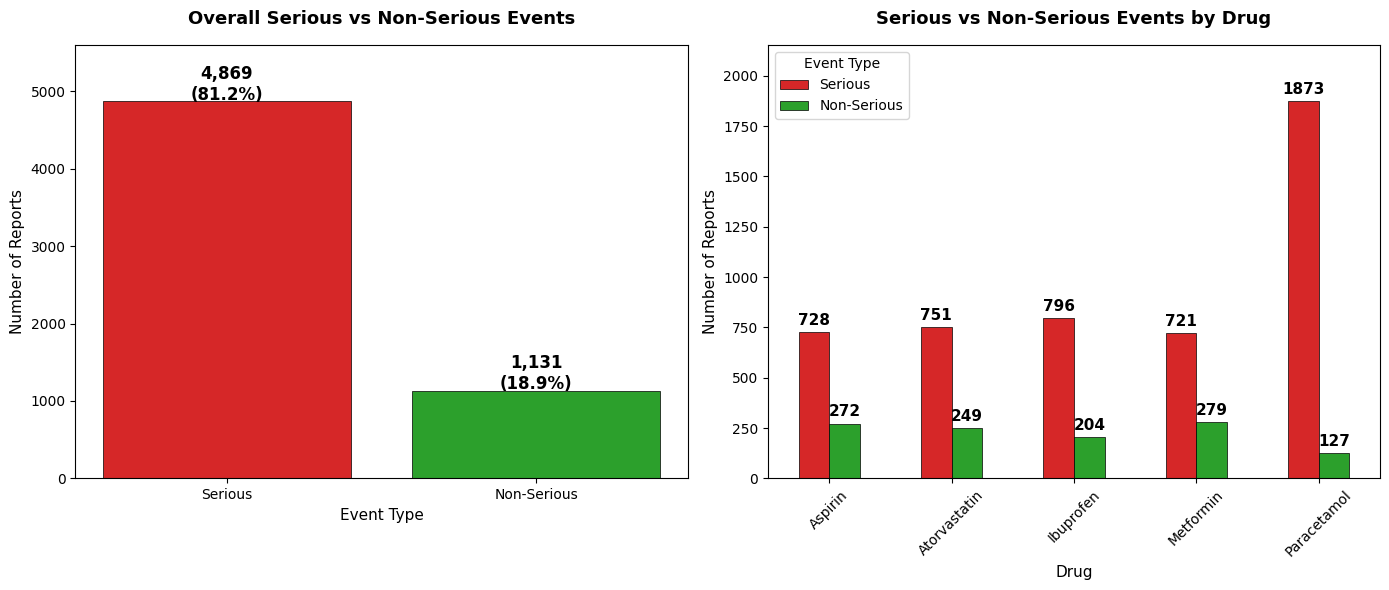

Analysis 1 complete


In [10]:
import os
os.makedirs('figures', exist_ok=True)
print("Figures folder ready")

# Analysis 1: Serious vs Non-Serious Events by Drug
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define consistent colours
color_serious = '#d62728'
color_non_serious = '#2ca02c'
colors = [color_serious, color_non_serious]

# Chart 1: Overall serious events
serious_counts = df['serious_label'].value_counts()
serious_counts = serious_counts.reindex(['Serious', 'Non-Serious'])
axes[0].bar(serious_counts.index, serious_counts.values, 
            color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Overall Serious vs Non-Serious Events', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Event Type', fontsize=11)
axes[0].set_ylabel('Number of Reports', fontsize=11)
axes[0].set_ylim(0, serious_counts.max() * 1.15)
for i, v in enumerate(serious_counts.values):
    axes[0].text(i, v + 20, 
                f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', fontsize=12, 
                fontweight='bold', color='black')

# Chart 2: Serious events by drug
serious_by_drug = df.groupby(
    ['drug_name', 'serious_label']).size().unstack(fill_value=0)
serious_by_drug = serious_by_drug[['Serious', 'Non-Serious']]
serious_by_drug.plot(kind='bar', ax=axes[1], 
                     color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Serious vs Non-Serious Events by Drug', 
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Drug', fontsize=11)
axes[1].set_ylabel('Number of Reports', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Event Type')
axes[1].set_ylim(0, serious_by_drug.max().max() * 1.15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', 
                      fontsize=11, fontweight='bold', padding=3)

plt.tight_layout()
plt.savefig('figures/analysis1_serious_events.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis 1 complete")

#### Analysis 2: Death Reports by Drug
Death reports were analysed across the five pharmaceutical products to identify which drugs were associated with the highest number of fatal adverse events. A death report was defined as any record where the seriousness death indicator was recorded as positive in the FAERS database.

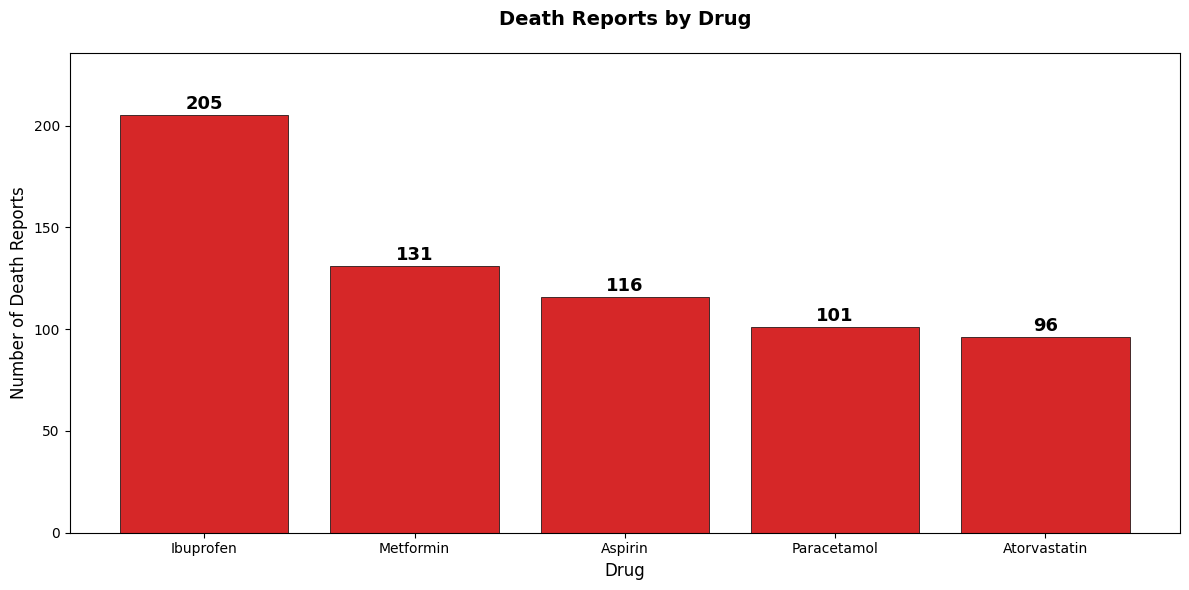

Analysis 2 complete


In [11]:
# Analysis 2: Death Reports by Drug
fig, ax = plt.subplots(figsize=(12, 6))

death_by_drug = df[df['seriousnessdeath'] == '1'].groupby(
    'drug_name').size().sort_values(ascending=False)

bars = ax.bar(death_by_drug.index, death_by_drug.values,
              color='#d62728', edgecolor='black', linewidth=0.5)

ax.set_title('Death Reports by Drug', fontsize=14, 
             fontweight='bold', pad=20)
ax.set_xlabel('Drug', fontsize=12)
ax.set_ylabel('Number of Death Reports', fontsize=12)
ax.set_ylim(0, death_by_drug.max() * 1.15)

for bar, v in zip(bars, death_by_drug.values):
    ax.text(bar.get_x() + bar.get_width()/2, 
            v + 1, f'{v:,}', 
            ha='center', va='bottom',
            fontsize=13, fontweight='bold',
            color='black')

plt.tight_layout()
plt.savefig('figures/analysis2_death_reports.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis 2 complete")

#### Analysis 3: Hospitalisation Reports by Drug
Hospitalisation reports were analysed across the five pharmaceutical products 
to identify which drugs were associated with the highest number of hospital 
admissions as a direct consequence of adverse events.

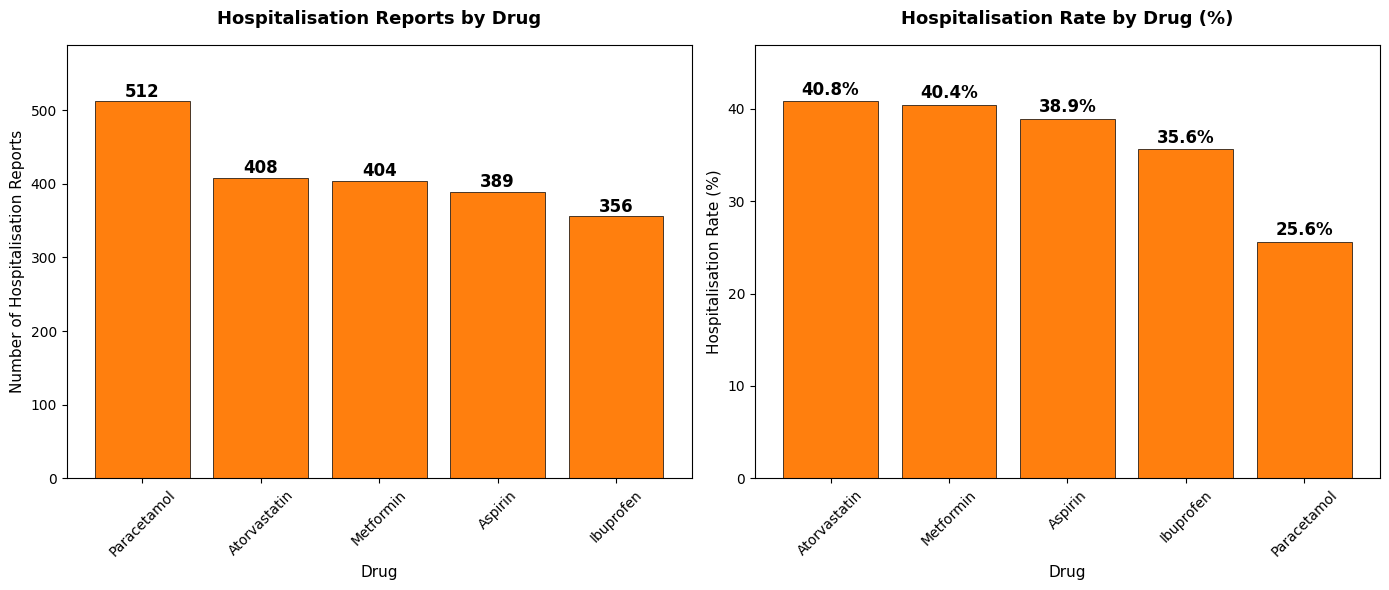

Analysis 3 complete


In [12]:
# Analysis 3: Hospitalisation Reports by Drug
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Hospitalisation counts by drug
hosp_by_drug = df[df['seriousnesshospitalisation'] == '1'].groupby(
    'drug_name').size().sort_values(ascending=False)

bars = axes[0].bar(hosp_by_drug.index, hosp_by_drug.values,
                   color='#ff7f0e', edgecolor='black', linewidth=0.5)
axes[0].set_title('Hospitalisation Reports by Drug', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Drug', fontsize=11)
axes[0].set_ylabel('Number of Hospitalisation Reports', fontsize=11)
axes[0].set_ylim(0, hosp_by_drug.max() * 1.15)
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, hosp_by_drug.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                v + 1, f'{v:,}',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

# Chart 2: Hospitalisation rate by drug
hosp_rate = df.groupby('drug_name').apply(
    lambda x: (x['seriousnesshospitalisation'] == '1').sum() / len(x) * 100
).sort_values(ascending=False)

bars2 = axes[1].bar(hosp_rate.index, hosp_rate.values,
                    color='#ff7f0e', edgecolor='black', linewidth=0.5)
axes[1].set_title('Hospitalisation Rate by Drug (%)', 
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Drug', fontsize=11)
axes[1].set_ylabel('Hospitalisation Rate (%)', fontsize=11)
axes[1].set_ylim(0, hosp_rate.max() * 1.15)
axes[1].tick_params(axis='x', rotation=45)
for bar, v in zip(bars2, hosp_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                v + 0.3, f'{v:.1f}%',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/analysis3_hospitalisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis 3 complete")

#### Analysis 4: Patient Sex Distribution by Drug
Adverse event reports were analysed by patient sex across the five 
pharmaceutical products to identify whether reporting patterns differed 
between male and female patients and to assess potential demographic 
risk profiles.

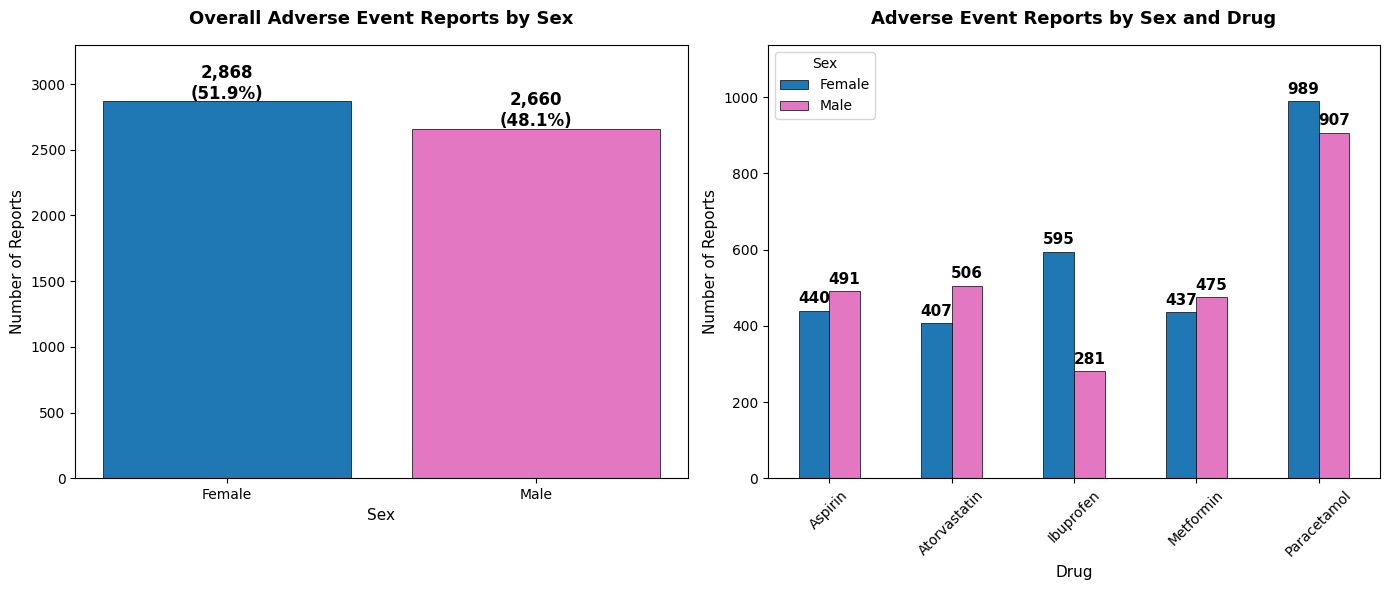

Analysis 4 complete


In [13]:
# Analysis 4: Patient Sex Distribution by Drug
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Overall sex distribution
sex_counts = df[df['sex_label'] != 'Unknown']['sex_label'].value_counts()
colors_sex = ['#1f77b4', '#e377c2']
axes[0].bar(sex_counts.index, sex_counts.values,
            color=colors_sex, edgecolor='black', linewidth=0.5)
axes[0].set_title('Overall Adverse Event Reports by Sex',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Sex', fontsize=11)
axes[0].set_ylabel('Number of Reports', fontsize=11)
axes[0].set_ylim(0, sex_counts.max() * 1.15)
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 20,
                f'{v:,}\n({v/sex_counts.sum()*100:.1f}%)',
                ha='center', fontsize=12, fontweight='bold')

# Chart 2: Sex distribution by drug
sex_by_drug = df[df['sex_label'] != 'Unknown'].groupby(
    ['drug_name', 'sex_label']).size().unstack(fill_value=0)
sex_by_drug = sex_by_drug[['Female', 'Male']]
sex_by_drug.plot(kind='bar', ax=axes[1],
                 color=colors_sex, edgecolor='black', linewidth=0.5)
axes[1].set_title('Adverse Event Reports by Sex and Drug',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Drug', fontsize=11)
axes[1].set_ylabel('Number of Reports', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sex')
axes[1].set_ylim(0, sex_by_drug.max().max() * 1.15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d',
                      fontsize=11, fontweight='bold', padding=3)

plt.tight_layout()
plt.savefig('figures/analysis4_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis 4 complete")

#### Analysis 5: Age Group Distribution by Drug
Adverse event reports were analysed by patient age group across the five 
pharmaceutical products. Age was not recorded in 15.1% of reports and 
these were classified as Unknown. Known age groups were dominated by 
patients aged 45 to 84, consistent with the chronic disease profile 
of the drugs analysed.

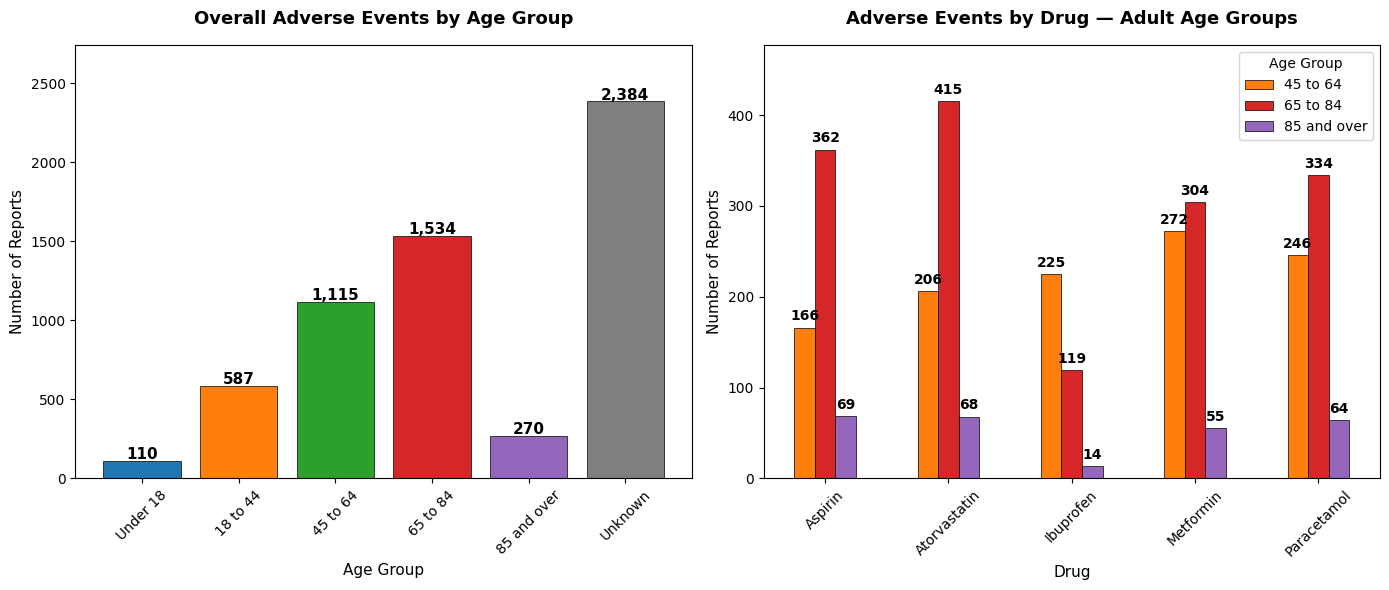

Analysis 5 complete


In [14]:
# Analysis 5: Age Group Distribution by Drug
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define age group order
age_order = ['Under 18', '18 to 44', '45 to 64', '65 to 84', '85 and over', 'Unknown']
colors_age = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#7f7f7f']

# Chart 1: Overall age group distribution
age_counts = df['age_group'].value_counts().reindex(age_order)
axes[0].bar(age_counts.index, age_counts.values,
            color=colors_age, edgecolor='black', linewidth=0.5)
axes[0].set_title('Overall Adverse Events by Age Group',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Age Group', fontsize=11)
axes[0].set_ylabel('Number of Reports', fontsize=11)
axes[0].set_ylim(0, age_counts.max() * 1.15)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 10, f'{v:,}',
                ha='center', fontsize=11, fontweight='bold')

# Chart 2: Age group by drug — top 3 age groups only for clarity
top_age_groups = ['45 to 64', '65 to 84', '85 and over']
age_by_drug = df[df['age_group'].isin(top_age_groups)].groupby(
    ['drug_name', 'age_group']).size().unstack(fill_value=0)
age_by_drug = age_by_drug[top_age_groups]
age_by_drug.plot(kind='bar', ax=axes[1],
                 color=['#ff7f0e', '#d62728', '#9467bd'],
                 edgecolor='black', linewidth=0.5)
axes[1].set_title('Adverse Events by Drug — Adult Age Groups',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Drug', fontsize=11)
axes[1].set_ylabel('Number of Reports', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Age Group')
axes[1].set_ylim(0, age_by_drug.max().max() * 1.15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d',
                      fontsize=10, fontweight='bold', padding=3)

plt.tight_layout()
plt.savefig('figures/analysis5_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis 5 complete")

#### Analysis 6: Top 20 Most Reported Adverse Reactions
The most frequently reported adverse reactions were identified across all five 
pharmaceutical products combined. Reaction terms were extracted from the FAERS 
MedDRA coded reaction fields and ranked by total frequency of occurrence.

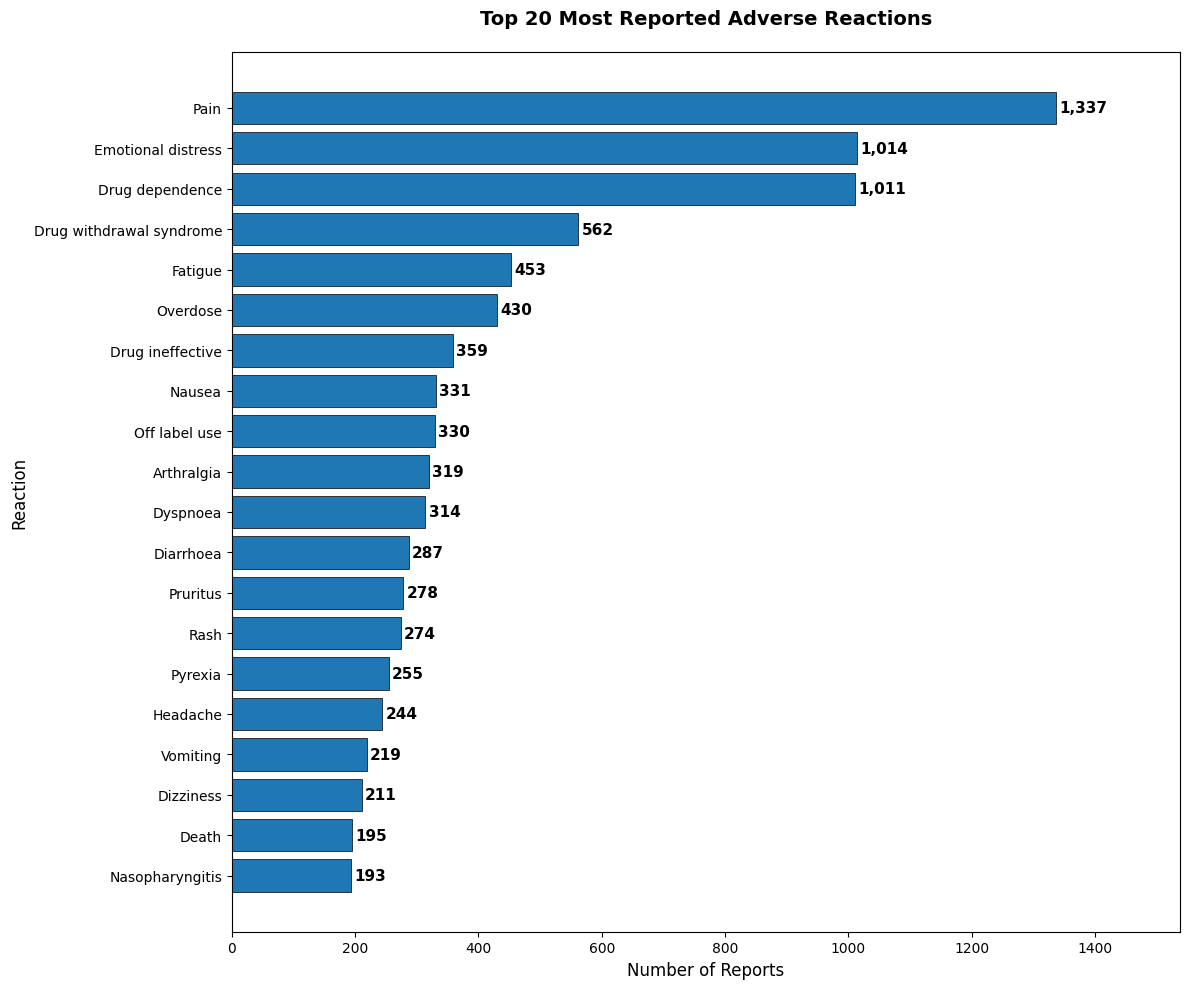

Analysis 6 complete


In [15]:
# Analysis 6: Top 20 Most Reported Adverse Reactions
fig, ax = plt.subplots(figsize=(12, 10))

reactions_exploded = df.explode('reactions')
reactions_exploded = reactions_exploded.dropna(subset=['reactions'])
top_reactions = reactions_exploded['reactions'].value_counts().head(20)

bars = ax.barh(top_reactions.index[::-1], top_reactions.values[::-1],
               color='#1f77b4', edgecolor='black', linewidth=0.5)
ax.set_title('Top 20 Most Reported Adverse Reactions', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Number of Reports', fontsize=12)
ax.set_ylabel('Reaction', fontsize=12)
ax.set_xlim(0, top_reactions.max() * 1.15)

for bar, v in zip(bars, top_reactions.values[::-1]):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/analysis6_top_reactions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis 6 complete")

#### Analysis 7: Monthly Adverse Event Trend
Monthly adverse event volumes were analysed across the full date range of 
the dataset to identify temporal patterns and trends in adverse event 
reporting over time.

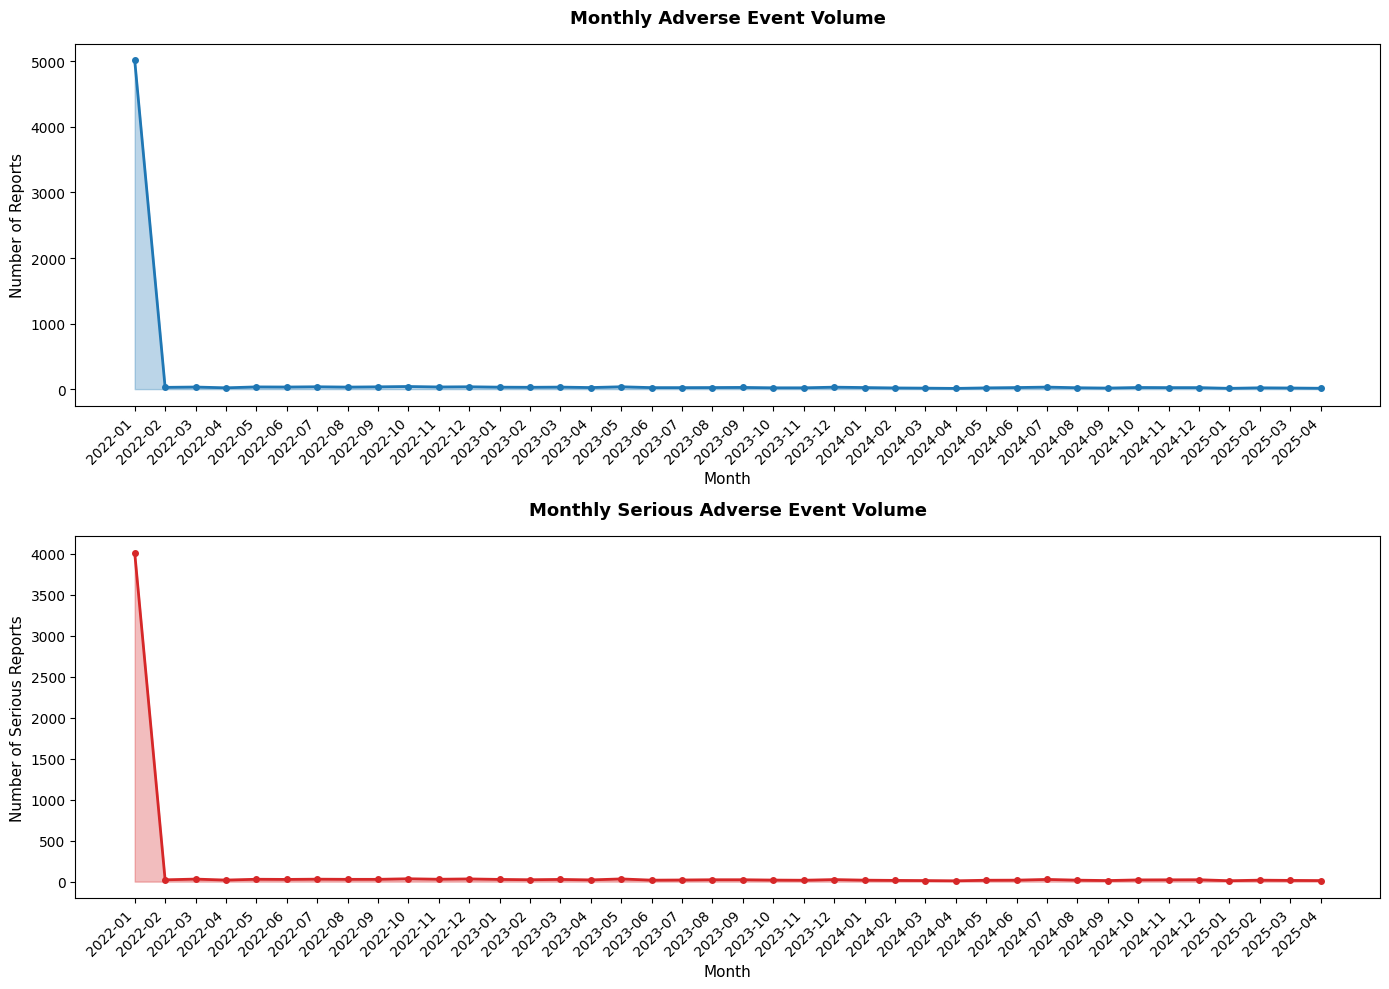

Analysis 7 complete


In [16]:
# Analysis 7: Monthly Adverse Event Trend
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1: Monthly total reports
monthly_counts = df.groupby('year_month').size()
monthly_counts.index = monthly_counts.index.astype(str)

axes[0].plot(monthly_counts.index, monthly_counts.values,
             color='#1f77b4', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(range(len(monthly_counts)), monthly_counts.values,
                     alpha=0.3, color='#1f77b4')
axes[0].set_title('Monthly Adverse Event Volume', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Number of Reports', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks(range(len(monthly_counts)))
axes[0].set_xticklabels(monthly_counts.index, rotation=45, ha='right')

# Chart 2: Monthly serious events
monthly_serious = df[df['serious_label'] == 'Serious'].groupby('year_month').size()
monthly_serious.index = monthly_serious.index.astype(str)

axes[1].plot(monthly_serious.index, monthly_serious.values,
             color='#d62728', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(range(len(monthly_serious)), monthly_serious.values,
                     alpha=0.3, color='#d62728')
axes[1].set_title('Monthly Serious Adverse Event Volume', 
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Number of Serious Reports', fontsize=11)
axes[1].set_xticks(range(len(monthly_serious)))
axes[1].set_xticklabels(monthly_serious.index, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('figures/analysis7_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis 7 complete")

In [ ]:
# Check date range of current dataset
print("=== DATE RANGE ANALYSIS ===\n")
print(f"Earliest report date: {df['receive_date'].min()}")
print(f"Latest report date: {df['receive_date'].max()}")
print(f"\nDate range: {(df['receive_date'].max() - df['receive_date'].min()).days} days")
print(f"\nReports by year:")
print(df['year'].value_counts().sort_index())
print(f"\nReports by month:")
print(df.groupby(['year', 'month']).size())